# 12C_model_comparison_lightgbm_xgboost.ipynb — Comparación LightGBM vs XGBoost

Este notebook compara los modelos ya entrenados:

```text
12_model_training_lightgbm.ipynb
12B_model_training_xgboost_risk.ipynb
```

Objetivo:

```text
Comparar el enfoque de regresión + riesgo derivado contra la clasificación directa de riesgo.
```

Modelos comparados:

```text
Persistence baseline
LightGBMRegressor → pred_hs → pred_risk
XGBClassifier     → pred_risk directo
```

Métricas principales:

```text
Regresión hs:
- MAE
- RMSE
- R²
- bias
- correlación

Riesgo:
- accuracy
- balanced_accuracy
- macro_f1
- weighted_f1
- recall clase 2
- recall clase 3
- f1 clase 2
- f1 clase 3
```

Salidas:

```text
gold/model_results/model_comparison/
```

Nota importante:

```text
Este notebook recalcula las métricas desde los ficheros de predicciones para evitar problemas de alineación de índices detectados anteriormente.
```

## Celda 0 — Montar Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Celda 1 — Instalar librerías

In [2]:
!pip -q install pandas numpy pyarrow scikit-learn matplotlib seaborn

## Celda 2 — Imports, rutas y configuración

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import warnings

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

BASE_DIR = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
GOLD_DIR = BASE_DIR / "gold"

LGBM_DIR = GOLD_DIR / "model_results" / "lightgbm"
XGB_DIR = GOLD_DIR / "model_results" / "xgboost_risk"
OUT_DIR = GOLD_DIR / "model_results" / "model_comparison"

OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS_HOURS = [3, 6, 12, 24]
RISK_CLASSES = [0, 1, 2, 3]

RISK_THRESHOLDS = {
    "low_max": 1.0,
    "moderate_max": 2.0,
    "high_max": 3.0,
}

print("LGBM_DIR:", LGBM_DIR, "existe:", LGBM_DIR.exists())
print("XGB_DIR:", XGB_DIR, "existe:", XGB_DIR.exists())
print("OUT_DIR:", OUT_DIR)

if not LGBM_DIR.exists():
    raise FileNotFoundError("No existe gold/model_results/lightgbm/. Ejecuta primero 12_model_training_lightgbm.ipynb.")

if not XGB_DIR.exists():
    raise FileNotFoundError("No existe gold/model_results/xgboost_risk/. Ejecuta primero 12B_model_training_xgboost_risk.ipynb.")

LGBM_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm existe: True
XGB_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk existe: True
OUT_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison


## Celda 3 — Funciones auxiliares

In [4]:
def risk_level_from_hs(values):
    values = pd.Series(np.asarray(values), dtype="float64")
    risk = pd.Series(np.nan, index=values.index, dtype="float64")

    risk.loc[values < RISK_THRESHOLDS["low_max"]] = 0
    risk.loc[(values >= RISK_THRESHOLDS["low_max"]) & (values < RISK_THRESHOLDS["moderate_max"])] = 1
    risk.loc[(values >= RISK_THRESHOLDS["moderate_max"]) & (values < RISK_THRESHOLDS["high_max"])] = 2
    risk.loc[values >= RISK_THRESHOLDS["high_max"]] = 3

    return risk.astype("Int64")


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(np.asarray(y_true), dtype="float64")
    y_pred = pd.Series(np.asarray(y_pred), dtype="float64")

    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "bias": np.nan,
            "corr": np.nan,
        }

    yt = y_true[mask].values
    yp = y_pred[mask].values

    return {
        "n": int(mask.sum()),
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "r2": float(r2_score(yt, yp)) if len(np.unique(yt)) > 1 else np.nan,
        "bias": float(np.mean(yp - yt)),
        "corr": float(np.corrcoef(yt, yp)[0, 1]) if len(yt) > 1 and np.std(yt) > 0 and np.std(yp) > 0 else np.nan,
    }


def classification_metrics(y_true, y_pred):
    y_true = pd.Series(np.asarray(y_true), dtype="Int64")
    y_pred = pd.Series(np.asarray(y_pred), dtype="Int64")

    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        out = {
            "n": 0,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
        }

        for cls in RISK_CLASSES:
            out[f"precision_class_{cls}"] = np.nan
            out[f"recall_class_{cls}"] = np.nan
            out[f"f1_class_{cls}"] = np.nan
            out[f"support_class_{cls}"] = 0

        return out

    yt = y_true[mask].astype(int).values
    yp = y_pred[mask].astype(int).values

    precision, recall, f1, support = precision_recall_fscore_support(
        yt,
        yp,
        labels=RISK_CLASSES,
        zero_division=0,
    )

    out = {
        "n": int(mask.sum()),
        "accuracy": float(accuracy_score(yt, yp)),
        "balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, labels=RISK_CLASSES, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(yt, yp, labels=RISK_CLASSES, average="weighted", zero_division=0)),
    }

    for i, cls in enumerate(RISK_CLASSES):
        out[f"precision_class_{cls}"] = float(precision[i])
        out[f"recall_class_{cls}"] = float(recall[i])
        out[f"f1_class_{cls}"] = float(f1[i])
        out[f"support_class_{cls}"] = int(support[i])

    return out


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def load_parquet_required(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}")
    return pd.read_parquet(path)


def load_csv_optional(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def plot_metric_by_horizon(df, metric, title, output_name):
    plt.figure(figsize=(9, 5))

    for model_name in df["model"].unique():
        data = df[df["model"] == model_name].sort_values("horizon_hours")
        plt.plot(data["horizon_hours"], data[metric], marker="o", label=model_name)

    plt.xlabel("Horizonte predictivo (h)")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / output_name, dpi=150)
    plt.show()

## Celda 4 — Cargar predicciones y métricas existentes

In [5]:
lgbm_pred_path = LGBM_DIR / "val_test_predictions.parquet"
xgb_pred_path = XGB_DIR / "val_test_predictions.parquet"

lgbm_pred = load_parquet_required(lgbm_pred_path)
xgb_pred = load_parquet_required(xgb_pred_path)

# Métricas originales, solo para referencia. Las recalcularemos.
lgbm_regression_original = load_csv_optional(LGBM_DIR / "metrics_regression.csv")
lgbm_risk_original = load_csv_optional(LGBM_DIR / "metrics_risk.csv")
xgb_risk_original = load_csv_optional(XGB_DIR / "metrics_risk.csv")

print("lgbm_pred:", lgbm_pred.shape)
print("xgb_pred:", xgb_pred.shape)

display(lgbm_pred.head())
display(xgb_pred.head())

print("Métricas originales disponibles:")
print("lgbm_regression_original:", lgbm_regression_original.shape)
print("lgbm_risk_original:", lgbm_risk_original.shape)
print("xgb_risk_original:", xgb_risk_original.shape)

lgbm_pred: (1043853, 18)
xgb_pred: (1043853, 19)


,zona_id,timestamp,split,isla,lat,lon,simar_hs,target_hs_3h,horizon_hours,y_true,pred_lgbm,pred_persistence,true_risk,pred_risk_lgbm,pred_risk_persistence,target_hs_6h,target_hs_12h,target_hs_24h
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.50,0.52,3,0.52,0.620382,0.50,0,0,0,NaN,NaN,NaN
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.45,0.79,3,0.79,0.569245,0.45,0,0,0,NaN,NaN,NaN
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.43,1.05,3,1.05,0.561176,0.43,1,0,0,NaN,NaN,NaN
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.52,1.22,3,1.22,0.705358,0.52,1,0,0,NaN,NaN,NaN
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.79,1.28,3,1.28,1.103930,0.79,1,1,0,NaN,NaN,NaN


,zona_id,timestamp,split,isla,lat,lon,simar_hs,target_risk_3h,horizon_hours,y_true_risk,pred_risk_xgb,pred_risk_persistence,proba_risk_0,proba_risk_1,proba_risk_2,proba_risk_3,target_risk_6h,target_risk_12h,target_risk_24h
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.50,0,3,0,0,0,0.980942,0.018985,0.000062,0.000010,<NA>,<NA>,<NA>
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.45,0,3,0,0,0,0.987905,0.012035,0.000048,0.000011,<NA>,<NA>,<NA>
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.43,1,3,1,0,0,0.976630,0.023288,0.000067,0.000014,<NA>,<NA>,<NA>
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.52,1,3,1,0,0,0.960945,0.038918,0.000102,0.000035,<NA>,<NA>,<NA>
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.79,1,3,1,1,0,0.459806,0.539881,0.000238,0.000075,<NA>,<NA>,<NA>


Métricas originales disponibles:
lgbm_regression_original: (24, 11)
lgbm_risk_original: (24, 8)
xgb_risk_original: (24, 27)


## Celda 5 — Recalcular métricas de regresión LightGBM

In [6]:
lgbm_regression_rows = []

for split in ["val", "test"]:
    for h in HORIZONS_HOURS:
        df_h = lgbm_pred[
            (lgbm_pred["split"] == split)
            & (lgbm_pred["horizon_hours"] == h)
        ].copy()

        if df_h.empty:
            print(f"AVISO: LightGBM predictions vacío para split={split}, h={h}")
            continue

        target_name = f"target_hs_{h}h"

        m_lgbm = regression_metrics(df_h["y_true"], df_h["pred_lgbm"])
        m_pers = regression_metrics(df_h["y_true"], df_h["pred_persistence"])

        lgbm_regression_rows.append(
            {
                "horizon_hours": h,
                "target": target_name,
                "split": split,
                "model": "LightGBMRegressor",
                **m_lgbm,
            }
        )

        lgbm_regression_rows.append(
            {
                "horizon_hours": h,
                "target": target_name,
                "split": split,
                "model": "Persistence",
                **m_pers,
            }
        )

lgbm_regression_recalc = pd.DataFrame(lgbm_regression_rows)
lgbm_regression_recalc.to_csv(OUT_DIR / "lgbm_regression_metrics_recalculated.csv", index=False)

display(lgbm_regression_recalc)

,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr
0,3,target_hs_3h,val,LightGBMRegressor,87300,0.058005,0.088922,0.985683,-0.000454,0.992857
1,3,target_hs_3h,val,Persistence,87300,0.082156,0.119858,0.973988,-0.000113,0.986993
2,6,target_hs_6h,val,LightGBMRegressor,87240,0.108338,0.156252,0.955825,0.000921,0.977882
3,6,target_hs_6h,val,Persistence,87240,0.143064,0.203847,0.924815,-0.000284,0.962399
4,12,target_hs_12h,val,LightGBMRegressor,87120,0.194558,0.270941,0.867363,0.005827,0.931801
5,12,target_hs_12h,val,Persistence,87120,0.233475,0.327556,0.806140,-0.000588,0.903017
6,24,target_hs_24h,val,LightGBMRegressor,87120,0.313081,0.419022,0.682594,0.019484,0.826813
7,24,target_hs_24h,val,Persistence,87120,0.354614,0.483992,0.576535,-0.000888,0.788108
8,3,target_hs_3h,test,LightGBMRegressor,174135,0.062603,0.099376,0.984963,-0.000656,0.992545
9,3,target_hs_3h,test,Persistence,174135,0.089138,0.130027,0.974257,0.000349,0.987132


## Celda 6 — Recalcular métricas de riesgo LightGBM derivado

In [7]:
lgbm_risk_rows = []
lgbm_confusion_rows = []

for split in ["val", "test"]:
    for h in HORIZONS_HOURS:
        df_h = lgbm_pred[
            (lgbm_pred["split"] == split)
            & (lgbm_pred["horizon_hours"] == h)
        ].copy()

        if df_h.empty:
            continue

        # Robustez: si faltan columnas de riesgo, derivarlas.
        true_risk = (
            df_h["true_risk"]
            if "true_risk" in df_h.columns
            else risk_level_from_hs(df_h["y_true"])
        )

        pred_risk_lgbm = (
            df_h["pred_risk_lgbm"]
            if "pred_risk_lgbm" in df_h.columns
            else risk_level_from_hs(df_h["pred_lgbm"])
        )

        pred_risk_persistence = (
            df_h["pred_risk_persistence"]
            if "pred_risk_persistence" in df_h.columns
            else risk_level_from_hs(df_h["pred_persistence"])
        )

        m_lgbm = classification_metrics(true_risk, pred_risk_lgbm)
        m_pers = classification_metrics(true_risk, pred_risk_persistence)

        lgbm_risk_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_risk_{h}h",
                "split": split,
                "model": "LightGBMRegressor_risk_derived",
                **m_lgbm,
            }
        )

        lgbm_risk_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_risk_{h}h",
                "split": split,
                "model": "PersistenceRisk",
                **m_pers,
            }
        )

        for model_name, pred_values in [
            ("LightGBMRegressor_risk_derived", pred_risk_lgbm),
            ("PersistenceRisk", pred_risk_persistence),
        ]:
            yt = pd.Series(np.asarray(true_risk), dtype="Int64")
            yp = pd.Series(np.asarray(pred_values), dtype="Int64")
            mask = yt.notna() & yp.notna()

            cm = confusion_matrix(
                yt[mask].astype(int),
                yp[mask].astype(int),
                labels=RISK_CLASSES,
            )

            pd.DataFrame(
                cm,
                index=[f"true_{i}" for i in RISK_CLASSES],
                columns=[f"pred_{i}" for i in RISK_CLASSES],
            ).to_csv(OUT_DIR / f"confusion_matrix_{model_name}_h{h}_{split}.csv")

lgbm_risk_recalc = pd.DataFrame(lgbm_risk_rows)
lgbm_risk_recalc.to_csv(OUT_DIR / "lgbm_risk_metrics_recalculated.csv", index=False)

display(lgbm_risk_recalc)

,horizon_hours,target,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_class_0,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,3,target_risk_3h,val,LightGBMRegressor_risk_derived,87300,0.948992,0.932388,0.939092,0.948916,0.952152,...,0.958456,44724,0.938131,0.936814,0.937472,23518,0.940283,0.884551,0.911566,4201
1,3,target_risk_3h,val,PersistenceRisk,87300,0.923219,0.909474,0.909533,0.923215,0.930120,...,0.937376,44724,0.902034,0.901267,0.901651,23518,0.869079,0.869079,0.869079,4201
2,6,target_risk_6h,val,LightGBMRegressor_risk_derived,87240,0.901032,0.865697,0.882035,0.900684,0.922822,...,0.919255,44665,0.875386,0.879405,0.877391,23525,0.898667,0.770531,0.829681,4201
3,6,target_risk_6h,val,PersistenceRisk,87240,0.865463,0.840270,0.840385,0.865444,0.879690,...,0.890808,44665,0.827220,0.825462,0.826340,23525,0.764818,0.764818,0.764818,4201
4,12,target_risk_12h,val,LightGBMRegressor_risk_derived,87120,0.822004,0.753436,0.782151,0.820672,0.882507,...,0.855925,44565,0.767152,0.790805,0.778799,23514,0.808819,0.572007,0.670106,4201
5,12,target_risk_12h,val,PersistenceRisk,87120,0.783437,0.739252,0.739433,0.783375,0.810490,...,0.825496,44565,0.720265,0.717232,0.718745,23514,0.603190,0.603190,0.603190,4201
6,24,target_risk_24h,val,LightGBMRegressor_risk_derived,87120,0.715680,0.590962,0.625724,0.709848,0.842435,...,0.771610,44583,0.625610,0.682186,0.652674,23498,0.649123,0.255476,0.366650,4200
7,24,target_risk_24h,val,PersistenceRisk,87120,0.679224,0.606435,0.606558,0.679100,0.731249,...,0.743779,44583,0.579799,0.576517,0.578153,23498,0.373006,0.373095,0.373051,4200
8,3,target_risk_3h,test,LightGBMRegressor_risk_derived,174135,0.944767,0.934673,0.939179,0.944729,0.941726,...,0.956700,91327,0.925868,0.927224,0.926546,43696,0.954737,0.917236,0.935611,13315
9,3,target_risk_3h,test,PersistenceRisk,174135,0.918489,0.909337,0.909224,0.918493,0.918590,...,0.937561,91327,0.885610,0.886077,0.885843,43696,0.894547,0.895757,0.895152,13315


## Celda 7 — Recalcular métricas de riesgo XGBClassifier

In [8]:
xgb_risk_rows = []

for split in ["val", "test"]:
    for h in HORIZONS_HOURS:
        df_h = xgb_pred[
            (xgb_pred["split"] == split)
            & (xgb_pred["horizon_hours"] == h)
        ].copy()

        if df_h.empty:
            print(f"AVISO: XGB predictions vacío para split={split}, h={h}")
            continue

        true_risk = df_h["y_true_risk"]
        pred_risk_xgb = df_h["pred_risk_xgb"]
        pred_risk_persistence = df_h["pred_risk_persistence"]

        m_xgb = classification_metrics(true_risk, pred_risk_xgb)
        m_pers = classification_metrics(true_risk, pred_risk_persistence)

        xgb_risk_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_risk_{h}h",
                "split": split,
                "model": "XGBClassifier_direct_risk",
                **m_xgb,
            }
        )

        xgb_risk_rows.append(
            {
                "horizon_hours": h,
                "target": f"target_risk_{h}h",
                "split": split,
                "model": "PersistenceRisk",
                **m_pers,
            }
        )

        for model_name, pred_values in [
            ("XGBClassifier_direct_risk", pred_risk_xgb),
            ("PersistenceRisk", pred_risk_persistence),
        ]:
            yt = pd.Series(np.asarray(true_risk), dtype="Int64")
            yp = pd.Series(np.asarray(pred_values), dtype="Int64")
            mask = yt.notna() & yp.notna()

            cm = confusion_matrix(
                yt[mask].astype(int),
                yp[mask].astype(int),
                labels=RISK_CLASSES,
            )

            pd.DataFrame(
                cm,
                index=[f"true_{i}" for i in RISK_CLASSES],
                columns=[f"pred_{i}" for i in RISK_CLASSES],
            ).to_csv(OUT_DIR / f"confusion_matrix_{model_name}_h{h}_{split}.csv")

xgb_risk_recalc = pd.DataFrame(xgb_risk_rows)
xgb_risk_recalc.to_csv(OUT_DIR / "xgb_risk_metrics_recalculated.csv", index=False)

display(xgb_risk_recalc)

,horizon_hours,target,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_class_0,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,3,target_risk_3h,val,XGBClassifier_direct_risk,87300,0.939141,0.947239,0.929302,0.939402,0.906318,...,0.949141,44724,0.913819,0.940514,0.926974,23518,0.859182,0.945489,0.900272,4201
1,3,target_risk_3h,val,PersistenceRisk,87300,0.923219,0.909474,0.909533,0.923215,0.930120,...,0.937376,44724,0.902034,0.901267,0.901651,23518,0.869079,0.869079,0.869079,4201
2,6,target_risk_6h,val,XGBClassifier_direct_risk,87240,0.882393,0.894053,0.864417,0.883177,0.840347,...,0.900625,44665,0.835032,0.877450,0.855716,23525,0.742461,0.879076,0.805014,4201
3,6,target_risk_6h,val,PersistenceRisk,87240,0.865463,0.840270,0.840385,0.865444,0.879690,...,0.890808,44665,0.827220,0.825462,0.826340,23525,0.764818,0.764818,0.764818,4201
4,12,target_risk_12h,val,XGBClassifier_direct_risk,87120,0.794238,0.790980,0.758827,0.796189,0.769772,...,0.824839,44565,0.711727,0.785915,0.746984,23514,0.571680,0.695787,0.627657,4201
5,12,target_risk_12h,val,PersistenceRisk,87120,0.783437,0.739252,0.739433,0.783375,0.810490,...,0.825496,44565,0.720265,0.717232,0.718745,23514,0.603190,0.603190,0.603190,4201
6,24,target_risk_24h,val,XGBClassifier_direct_risk,87120,0.650172,0.639722,0.592436,0.659488,0.694136,...,0.700340,44583,0.558954,0.607456,0.582196,23498,0.252900,0.503571,0.336703,4200
7,24,target_risk_24h,val,PersistenceRisk,87120,0.679224,0.606435,0.606558,0.679100,0.731249,...,0.743779,44583,0.579799,0.576517,0.578153,23498,0.373006,0.373095,0.373051,4200
8,3,target_risk_3h,test,XGBClassifier_direct_risk,174135,0.934775,0.946344,0.930576,0.935083,0.892036,...,0.946876,91327,0.896956,0.932694,0.914476,43696,0.903854,0.958092,0.930183,13315
9,3,target_risk_3h,test,PersistenceRisk,174135,0.918489,0.909337,0.909224,0.918493,0.918590,...,0.937561,91327,0.885610,0.886077,0.885843,43696,0.894547,0.895757,0.895152,13315


## Celda 8 — Consolidar comparación de riesgo

In [9]:
# Para comparar, no duplicamos PersistenceRisk de ambas fuentes.
risk_comparison = pd.concat(
    [
        lgbm_risk_recalc[lgbm_risk_recalc["model"] == "LightGBMRegressor_risk_derived"],
        xgb_risk_recalc[xgb_risk_recalc["model"] == "XGBClassifier_direct_risk"],
        xgb_risk_recalc[xgb_risk_recalc["model"] == "PersistenceRisk"],
    ],
    ignore_index=True,
)

risk_comparison.to_csv(OUT_DIR / "comparison_risk_metrics.csv", index=False)

display(risk_comparison)

risk_test = risk_comparison[risk_comparison["split"] == "test"].copy()

risk_test_wide = risk_test.pivot_table(
    index=["horizon_hours", "target"],
    columns="model",
    values=[
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1",
        "recall_class_2",
        "recall_class_3",
        "f1_class_2",
        "f1_class_3",
    ],
)

display(risk_test_wide)

risk_test_wide.to_csv(OUT_DIR / "comparison_risk_metrics_test_wide.csv")

,horizon_hours,target,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_class_0,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,3,target_risk_3h,val,LightGBMRegressor_risk_derived,87300,0.948992,0.932388,0.939092,0.948916,0.952152,...,0.958456,44724,0.938131,0.936814,0.937472,23518,0.940283,0.884551,0.911566,4201
1,6,target_risk_6h,val,LightGBMRegressor_risk_derived,87240,0.901032,0.865697,0.882035,0.900684,0.922822,...,0.919255,44665,0.875386,0.879405,0.877391,23525,0.898667,0.770531,0.829681,4201
2,12,target_risk_12h,val,LightGBMRegressor_risk_derived,87120,0.822004,0.753436,0.782151,0.820672,0.882507,...,0.855925,44565,0.767152,0.790805,0.778799,23514,0.808819,0.572007,0.670106,4201
3,24,target_risk_24h,val,LightGBMRegressor_risk_derived,87120,0.715680,0.590962,0.625724,0.709848,0.842435,...,0.771610,44583,0.625610,0.682186,0.652674,23498,0.649123,0.255476,0.366650,4200
4,3,target_risk_3h,test,LightGBMRegressor_risk_derived,174135,0.944767,0.934673,0.939179,0.944729,0.941726,...,0.956700,91327,0.925868,0.927224,0.926546,43696,0.954737,0.917236,0.935611,13315
5,6,target_risk_6h,test,LightGBMRegressor_risk_derived,173958,0.896803,0.871643,0.883351,0.896622,0.912334,...,0.921302,91245,0.851217,0.867681,0.859370,43637,0.909826,0.821012,0.863140,13297
6,12,target_risk_12h,test,LightGBMRegressor_risk_derived,173604,0.814929,0.762452,0.785569,0.814217,0.866451,...,0.860826,91061,0.723821,0.771673,0.746982,43534,0.832505,0.643482,0.725889,13270
7,24,target_risk_24h,test,LightGBMRegressor_risk_derived,173376,0.704342,0.596647,0.629172,0.698370,0.819444,...,0.782875,90914,0.560411,0.635241,0.595484,43489,0.714132,0.299902,0.422411,13261
8,3,target_risk_3h,val,XGBClassifier_direct_risk,87300,0.939141,0.947239,0.929302,0.939402,0.906318,...,0.949141,44724,0.913819,0.940514,0.926974,23518,0.859182,0.945489,0.900272,4201
9,6,target_risk_6h,val,XGBClassifier_direct_risk,87240,0.882393,0.894053,0.864417,0.883177,0.840347,...,0.900625,44665,0.835032,0.877450,0.855716,23525,0.742461,0.879076,0.805014,4201


accuracy                  \
model                         LightGBMRegressor_risk_derived PersistenceRisk   
horizon_hours target                                                           
3             target_risk_3h                        0.944767        0.918489   
6             target_risk_6h                        0.896803        0.858684   
12            target_risk_12h                       0.814929        0.773001   
24            target_risk_24h                       0.704342        0.666546   

                                                         \
model                         XGBClassifier_direct_risk   
horizon_hours target                                      
3             target_risk_3h                   0.934775   
6             target_risk_6h                   0.878315   
12            target_risk_12h                  0.786606   
24            target_risk_24h                  0.649848   

                                           balanced_accuracy                  \
model                         LightGBMRegressor_risk_derived PersistenceRisk   
horizon_hours target                                                           
3             target_risk_3h                        0.934673        0.909337   
6             target_risk_6h                        0.871643        0.841002   
12            target_risk_12h                       0.762452        0.740646   
24            target_risk_24h                       0.596647        0.614597   

                                                         \
model                         XGBClassifier_direct_risk   
horizon_hours target                                      
3             target_risk_3h                   0.946344   
6             target_risk_6h                   0.894486   
12            target_risk_12h                  0.798065   
24            target_risk_24h                  0.665456   

                                                  f1_class_2                  \
model                         LightGBMRegressor_risk_derived PersistenceRisk   
horizon_hours target                                                           
3             target_risk_3h                        0.926546        0.885843   
6             target_risk_6h                        0.859370        0.799267   
12            target_risk_12h                       0.746982        0.674168   
24            target_risk_24h                       0.595484        0.523880   

                                                         \
model                         XGBClassifier_direct_risk   
horizon_hours target                                      
3             target_risk_3h                   0.914476   
6             target_risk_6h                   0.837669   
12            target_risk_12h                  0.714087   
24            target_risk_24h                  0.549142   

                                                  f1_class_3  ...  \
model                         LightGBMRegressor_risk_derived  ...   
horizon_hours target                                          ...   
3             target_risk_3h                        0.935611  ...   
6             target_risk_6h                        0.863140  ...   
12            target_risk_12h                       0.725889  ...   
24            target_risk_24h                       0.422411  ...   

                                               macro_f1  \
model                         XGBClassifier_direct_risk   
horizon_hours target                                      
3             target_risk_3h                   0.930576   
6             target_risk_6h                   0.869121   
12            target_risk_12h                  0.766844   
24            target_risk_24h                  0.622502   

                                              recall_class_2                  \
model                         LightGBMRegressor_risk_derived PersistenceRisk   
horizon_hours target                                                 

## Celda 9 — Comparar LightGBM vs XGB por horizonte

In [10]:
comparison_rows = []

metrics_to_compare = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "recall_class_2",
    "recall_class_3",
    "f1_class_2",
    "f1_class_3",
]

for h in HORIZONS_HOURS:
    subset = risk_test[risk_test["horizon_hours"] == h].copy()

    rows = {
        row["model"]: row
        for _, row in subset.iterrows()
    }

    if "LightGBMRegressor_risk_derived" not in rows or "XGBClassifier_direct_risk" not in rows:
        continue

    lgbm = rows["LightGBMRegressor_risk_derived"]
    xgb = rows["XGBClassifier_direct_risk"]
    pers = rows.get("PersistenceRisk")

    item = {
        "horizon_hours": h,
        "recommended_model_macro_f1": "XGBClassifier_direct_risk" if xgb["macro_f1"] > lgbm["macro_f1"] else "LightGBMRegressor_risk_derived",
        "recommended_model_balanced_accuracy": "XGBClassifier_direct_risk" if xgb["balanced_accuracy"] > lgbm["balanced_accuracy"] else "LightGBMRegressor_risk_derived",
        "recommended_model_recall_class_3": "XGBClassifier_direct_risk" if xgb["recall_class_3"] > lgbm["recall_class_3"] else "LightGBMRegressor_risk_derived",
        "macro_f1_lgbm": lgbm["macro_f1"],
        "macro_f1_xgb": xgb["macro_f1"],
        "macro_f1_delta_xgb_minus_lgbm": xgb["macro_f1"] - lgbm["macro_f1"],
        "balanced_accuracy_lgbm": lgbm["balanced_accuracy"],
        "balanced_accuracy_xgb": xgb["balanced_accuracy"],
        "balanced_accuracy_delta_xgb_minus_lgbm": xgb["balanced_accuracy"] - lgbm["balanced_accuracy"],
        "accuracy_lgbm": lgbm["accuracy"],
        "accuracy_xgb": xgb["accuracy"],
        "accuracy_delta_xgb_minus_lgbm": xgb["accuracy"] - lgbm["accuracy"],
        "recall_class_2_lgbm": lgbm["recall_class_2"],
        "recall_class_2_xgb": xgb["recall_class_2"],
        "recall_class_2_delta_xgb_minus_lgbm": xgb["recall_class_2"] - lgbm["recall_class_2"],
        "recall_class_3_lgbm": lgbm["recall_class_3"],
        "recall_class_3_xgb": xgb["recall_class_3"],
        "recall_class_3_delta_xgb_minus_lgbm": xgb["recall_class_3"] - lgbm["recall_class_3"],
    }

    if pers is not None:
        item.update(
            {
                "macro_f1_persistence": pers["macro_f1"],
                "xgb_macro_f1_delta_vs_persistence": xgb["macro_f1"] - pers["macro_f1"],
                "lgbm_macro_f1_delta_vs_persistence": lgbm["macro_f1"] - pers["macro_f1"],
                "accuracy_persistence": pers["accuracy"],
                "xgb_accuracy_delta_vs_persistence": xgb["accuracy"] - pers["accuracy"],
                "lgbm_accuracy_delta_vs_persistence": lgbm["accuracy"] - pers["accuracy"],
            }
        )

    comparison_rows.append(item)

model_vs_model_comparison = pd.DataFrame(comparison_rows)
model_vs_model_comparison.to_csv(OUT_DIR / "comparison_lightgbm_vs_xgboost_test.csv", index=False)

display(model_vs_model_comparison)

,horizon_hours,recommended_model_macro_f1,recommended_model_balanced_accuracy,recommended_model_recall_class_3,macro_f1_lgbm,macro_f1_xgb,macro_f1_delta_xgb_minus_lgbm,balanced_accuracy_lgbm,balanced_accuracy_xgb,balanced_accuracy_delta_xgb_minus_lgbm,...,recall_class_2_delta_xgb_minus_lgbm,recall_class_3_lgbm,recall_class_3_xgb,recall_class_3_delta_xgb_minus_lgbm,macro_f1_persistence,xgb_macro_f1_delta_vs_persistence,lgbm_macro_f1_delta_vs_persistence,accuracy_persistence,xgb_accuracy_delta_vs_persistence,lgbm_accuracy_delta_vs_persistence
0,3,LightGBMRegressor_risk_derived,XGBClassifier_direct_risk,XGBClassifier_direct_risk,0.939179,0.930576,-0.008603,0.934673,0.946344,0.011670,...,0.005470,0.917236,0.958092,0.040856,0.909224,0.021352,0.029955,0.918489,0.016286,0.026278
1,6,LightGBMRegressor_risk_derived,XGBClassifier_direct_risk,XGBClassifier_direct_risk,0.883351,0.869121,-0.014230,0.871643,0.894486,0.022843,...,0.002612,0.821012,0.895014,0.074002,0.840787,0.028334,0.042564,0.858684,0.019631,0.038118
2,12,LightGBMRegressor_risk_derived,XGBClassifier_direct_risk,XGBClassifier_direct_risk,0.785569,0.766844,-0.018725,0.762452,0.798065,0.035614,...,-0.003767,0.643482,0.744989,0.101507,0.740397,0.026447,0.045172,0.773001,0.013606,0.041929
3,24,LightGBMRegressor_risk_derived,XGBClassifier_direct_risk,XGBClassifier_direct_risk,0.629172,0.622502,-0.006670,0.596647,0.665456,0.068810,...,-0.029801,0.299902,0.597165,0.297263,0.614795,0.007707,0.014378,0.666546,-0.016698,0.037796


## Celda 10 — Recomendación automática por horizonte

In [11]:
recommendation_rows = []

for _, row in model_vs_model_comparison.iterrows():
    h = int(row["horizon_hours"])

    # Score compuesto orientado a seguridad:
    # macro_f1 y balanced_accuracy son generales.
    # recall_class_3 tiene peso extra por eventos extremos.
    score_lgbm = (
        0.35 * row["macro_f1_lgbm"]
        + 0.30 * row["balanced_accuracy_lgbm"]
        + 0.20 * row["recall_class_3_lgbm"]
        + 0.15 * row["recall_class_2_lgbm"]
    )

    score_xgb = (
        0.35 * row["macro_f1_xgb"]
        + 0.30 * row["balanced_accuracy_xgb"]
        + 0.20 * row["recall_class_3_xgb"]
        + 0.15 * row["recall_class_2_xgb"]
    )

    if score_xgb > score_lgbm:
        recommended = "XGBClassifier_direct_risk"
        reason = "Mejor score compuesto de seguridad."
    else:
        recommended = "LightGBMRegressor_risk_derived"
        reason = "Mejor score compuesto de seguridad."

    # Si una diferencia es muy pequeña, marcar como empate práctico.
    if abs(score_xgb - score_lgbm) < 0.005:
        recommended = "Tie_or_ensemble_candidate"
        reason = "Diferencia de score < 0.005; ambos son muy similares."

    recommendation_rows.append(
        {
            "horizon_hours": h,
            "recommended_model": recommended,
            "score_lgbm": score_lgbm,
            "score_xgb": score_xgb,
            "score_delta_xgb_minus_lgbm": score_xgb - score_lgbm,
            "reason": reason,
        }
    )

recommendation_summary = pd.DataFrame(recommendation_rows)
recommendation_summary.to_csv(OUT_DIR / "recommendation_by_horizon.csv", index=False)

display(recommendation_summary)

,horizon_hours,recommended_model,score_lgbm,score_xgb,score_delta_xgb_minus_lgbm,reason
0,3,XGBClassifier_direct_risk,0.931645,0.941127,0.009482,Mejor score compuesto de seguridad.
1,6,XGBClassifier_direct_risk,0.865020,0.882085,0.017065,Mejor score compuesto de seguridad.
2,12,XGBClassifier_direct_risk,0.748132,0.771998,0.023867,Mejor score compuesto de seguridad.
3,24,XGBClassifier_direct_risk,0.554471,0.627762,0.073291,Mejor score compuesto de seguridad.


## Celda 11 — Gráficos comparativos de riesgo

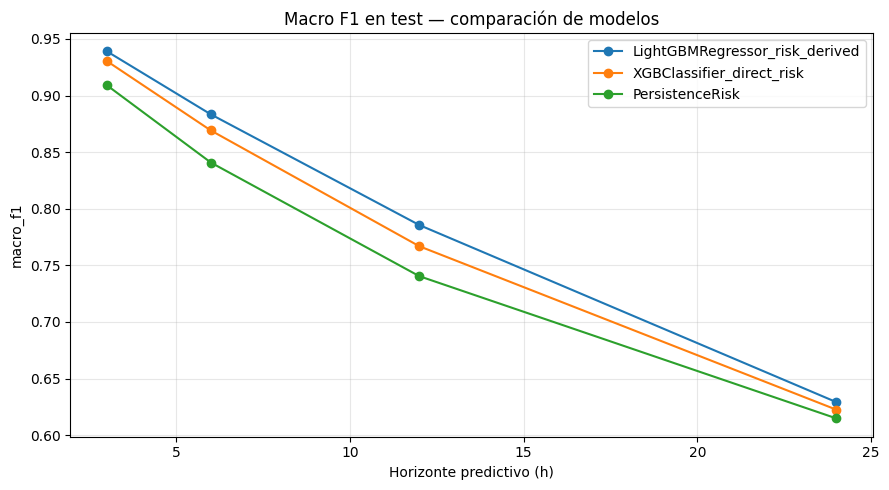

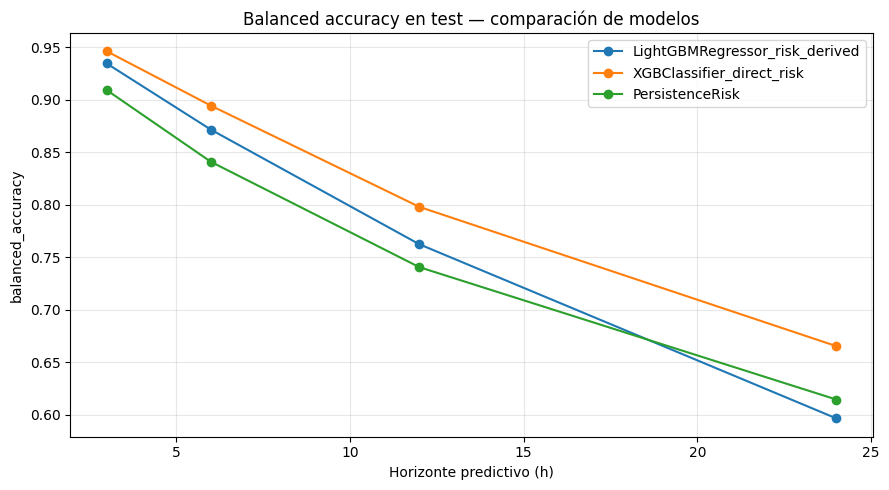

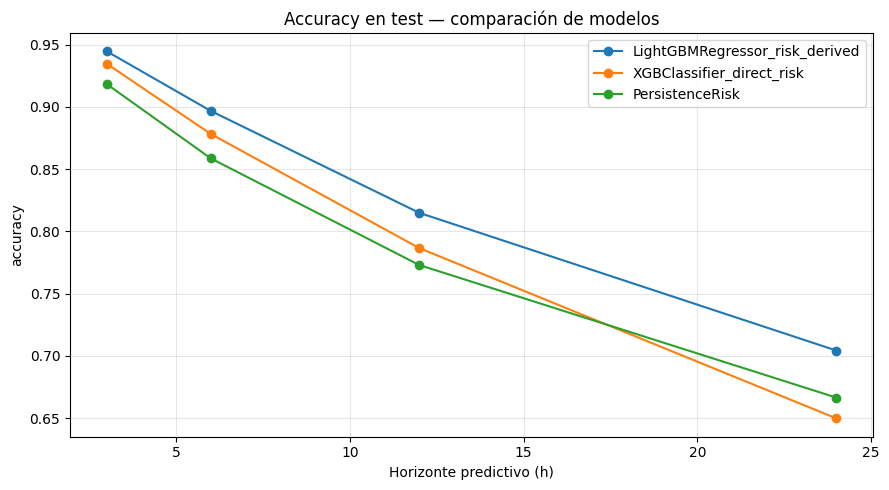

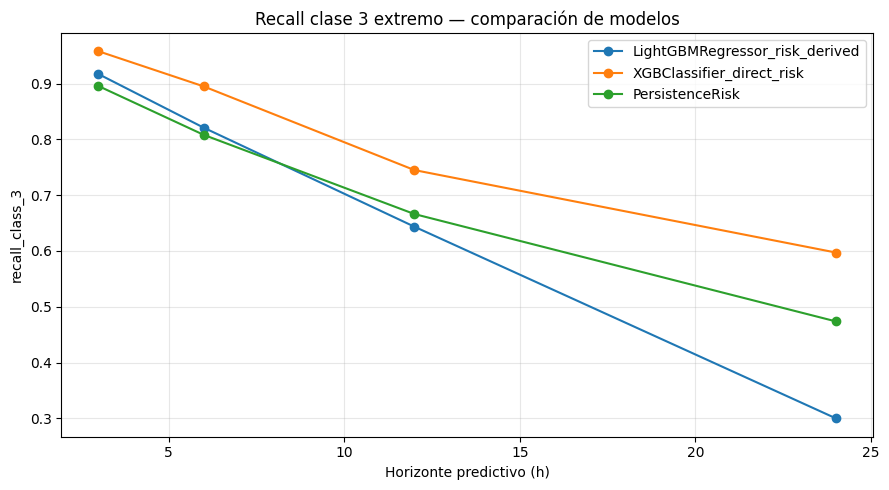

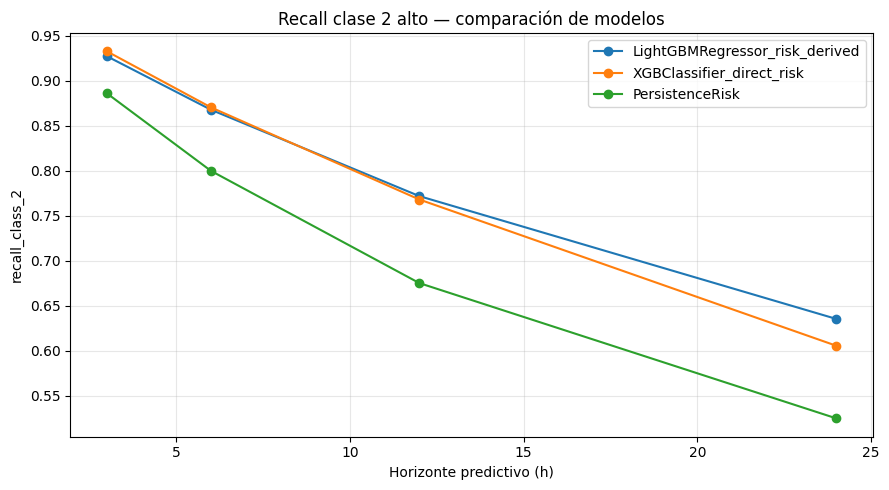

In [12]:
plot_metric_by_horizon(
    risk_test,
    metric="macro_f1",
    title="Macro F1 en test — comparación de modelos",
    output_name="plot_comparison_macro_f1_test.png",
)

plot_metric_by_horizon(
    risk_test,
    metric="balanced_accuracy",
    title="Balanced accuracy en test — comparación de modelos",
    output_name="plot_comparison_balanced_accuracy_test.png",
)

plot_metric_by_horizon(
    risk_test,
    metric="accuracy",
    title="Accuracy en test — comparación de modelos",
    output_name="plot_comparison_accuracy_test.png",
)

plot_metric_by_horizon(
    risk_test,
    metric="recall_class_3",
    title="Recall clase 3 extremo — comparación de modelos",
    output_name="plot_comparison_recall_class_3_test.png",
)

plot_metric_by_horizon(
    risk_test,
    metric="recall_class_2",
    title="Recall clase 2 alto — comparación de modelos",
    output_name="plot_comparison_recall_class_2_test.png",
)

## Celda 12 — Gráficos de regresión LightGBM vs persistencia

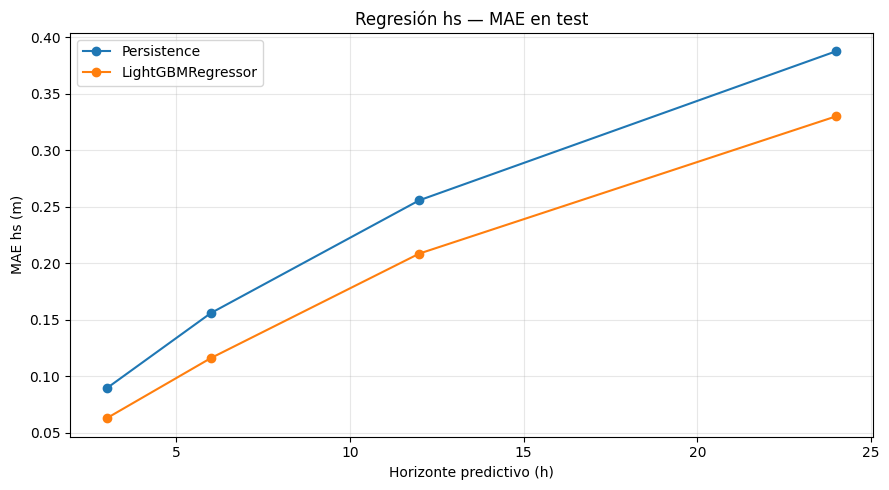

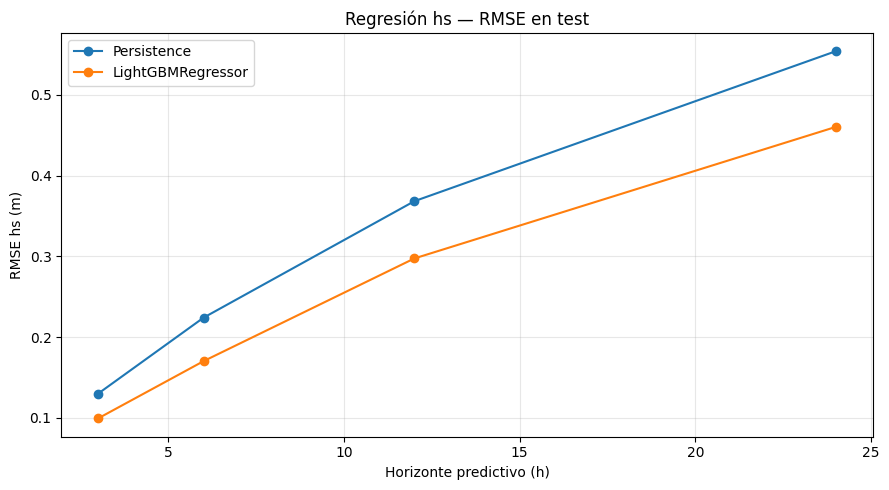

,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr
8,3,target_hs_3h,test,LightGBMRegressor,174135,0.062603,0.099376,0.984963,-0.000656,0.992545
9,3,target_hs_3h,test,Persistence,174135,0.089138,0.130027,0.974257,0.000349,0.987132
10,6,target_hs_6h,test,LightGBMRegressor,173958,0.115955,0.170217,0.955884,0.000212,0.978034
11,6,target_hs_6h,test,Persistence,173958,0.155820,0.224067,0.923556,0.000729,0.961796
12,12,target_hs_12h,test,LightGBMRegressor,173604,0.208555,0.297417,0.865371,0.000439,0.931078
13,12,target_hs_12h,test,Persistence,173604,0.255759,0.368320,0.793529,0.001481,0.896824
14,24,target_hs_24h,test,LightGBMRegressor,173376,0.330201,0.460345,0.677494,-0.009273,0.824775
15,24,target_hs_24h,test,Persistence,173376,0.387839,0.554102,0.532749,0.001743,0.766396


In [13]:
lgbm_reg_test = lgbm_regression_recalc[lgbm_regression_recalc["split"] == "test"].copy()

plt.figure(figsize=(9, 5))

for model_name in ["Persistence", "LightGBMRegressor"]:
    data = lgbm_reg_test[lgbm_reg_test["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["mae"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("MAE hs (m)")
plt.title("Regresión hs — MAE en test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_lgbm_regression_mae_test.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))

for model_name in ["Persistence", "LightGBMRegressor"]:
    data = lgbm_reg_test[lgbm_reg_test["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["rmse"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("RMSE hs (m)")
plt.title("Regresión hs — RMSE en test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_lgbm_regression_rmse_test.png", dpi=150)
plt.show()

display(lgbm_reg_test)

## Celda 13 — Matrices de confusión principales

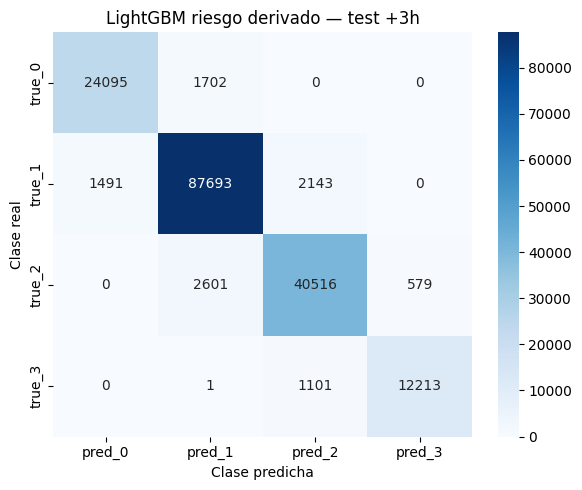

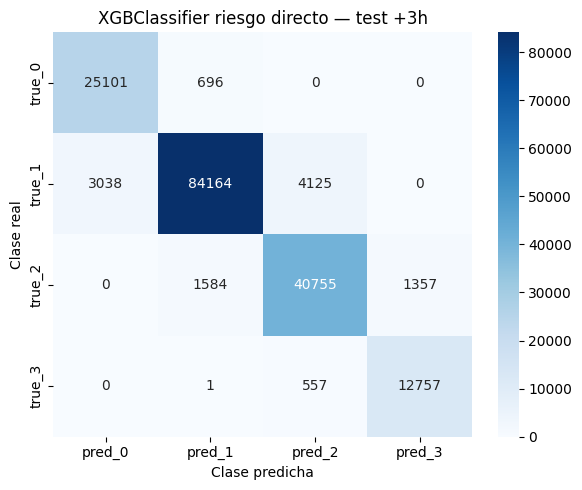

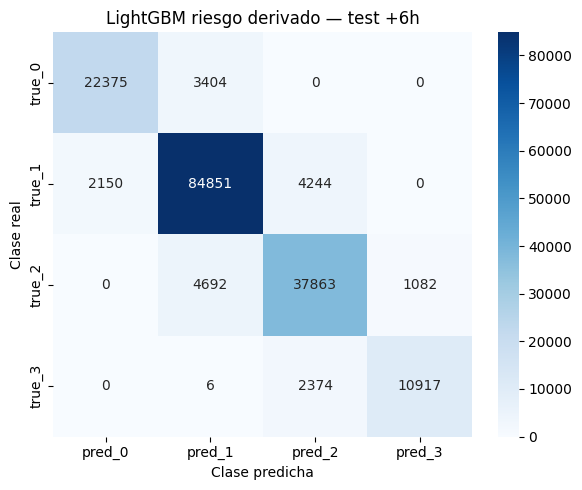

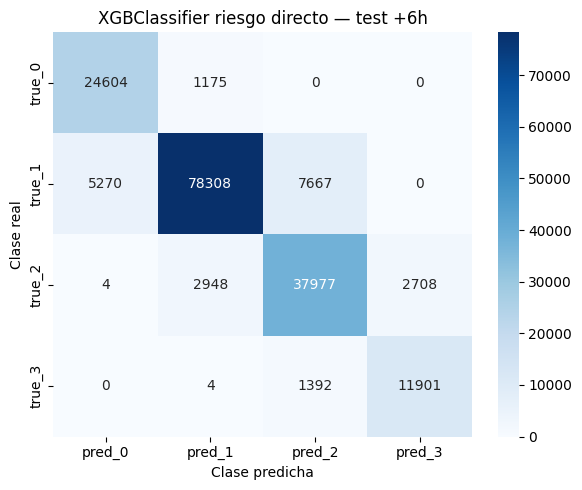

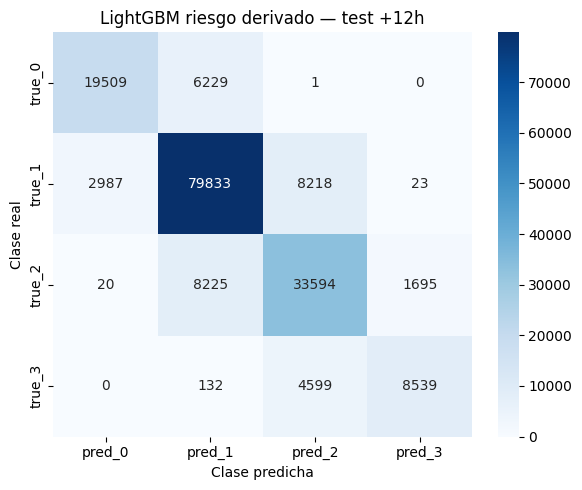

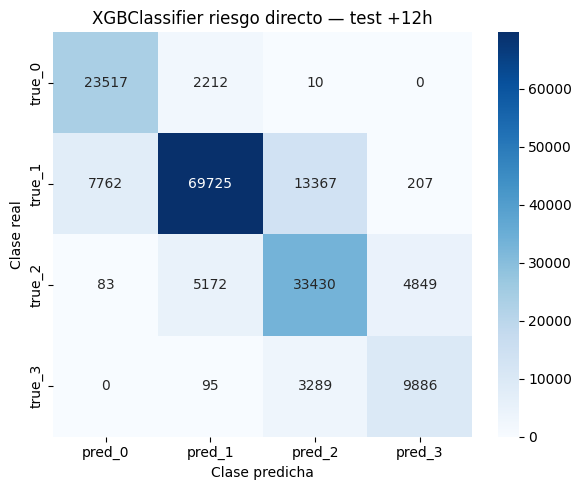

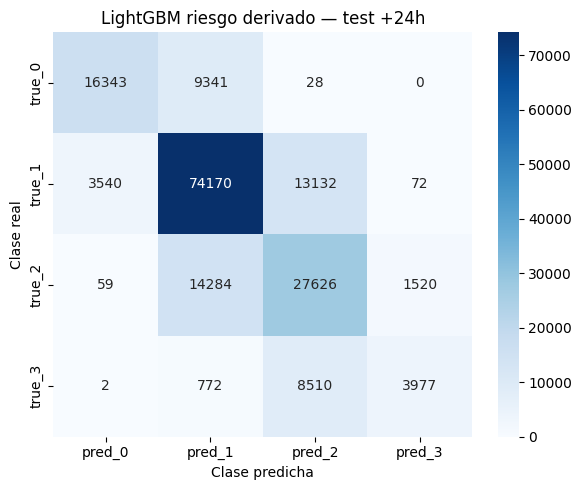

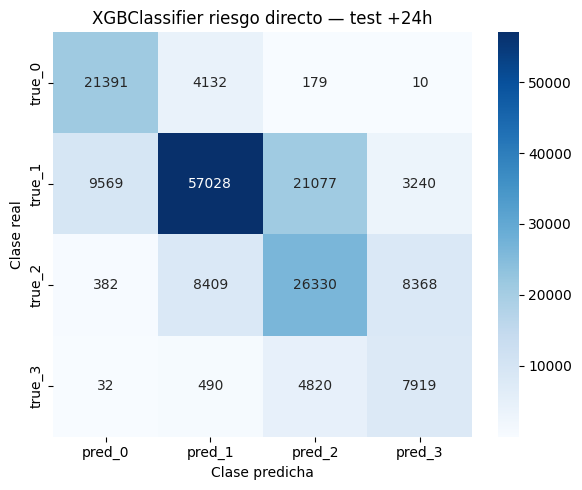

In [14]:
def plot_confusion_from_predictions(df, true_col, pred_col, title, output_name):
    yt = pd.Series(np.asarray(df[true_col]), dtype="Int64")
    yp = pd.Series(np.asarray(df[pred_col]), dtype="Int64")
    mask = yt.notna() & yp.notna()

    cm = confusion_matrix(
        yt[mask].astype(int),
        yp[mask].astype(int),
        labels=RISK_CLASSES,
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{i}" for i in RISK_CLASSES],
        columns=[f"pred_{i}" for i in RISK_CLASSES],
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("Clase real")
    plt.xlabel("Clase predicha")
    plt.tight_layout()
    plt.savefig(OUT_DIR / output_name, dpi=150)
    plt.show()

    return cm_df


for h in HORIZONS_HOURS:
    lgbm_df = lgbm_pred[
        (lgbm_pred["split"] == "test")
        & (lgbm_pred["horizon_hours"] == h)
    ].copy()

    xgb_df = xgb_pred[
        (xgb_pred["split"] == "test")
        & (xgb_pred["horizon_hours"] == h)
    ].copy()

    if not lgbm_df.empty:
        plot_confusion_from_predictions(
            lgbm_df,
            true_col="true_risk",
            pred_col="pred_risk_lgbm",
            title=f"LightGBM riesgo derivado — test +{h}h",
            output_name=f"plot_confusion_lgbm_test_h{h}.png",
        )

    if not xgb_df.empty:
        plot_confusion_from_predictions(
            xgb_df,
            true_col="y_true_risk",
            pred_col="pred_risk_xgb",
            title=f"XGBClassifier riesgo directo — test +{h}h",
            output_name=f"plot_confusion_xgb_test_h{h}.png",
        )

## Celda 14 — Comparación de importancia de variables

,feature,importance_gain,importance_split,horizon_hours,model_family,importance_weight
0,simar_hs,4.827723e+06,8518.0,3,LightGBMRegressor,NaN
1,simar_hs_lag_1h,7.429433e+05,7048.0,3,LightGBMRegressor,NaN
2,simar_hs_lag_3h,1.471515e+05,4192.0,3,LightGBMRegressor,NaN
3,simar_hs_roll_mean_6h,2.865419e+04,1307.0,3,LightGBMRegressor,NaN
4,simar_hs_lag_6h,5.503086e+03,2776.0,3,LightGBMRegressor,NaN
...,...,...,...,...,...,...
155,simar_v10,7.284702e+01,NaN,24,XGBClassifier,2847.0
156,year,7.192649e+01,NaN,24,XGBClassifier,4796.0
157,month_sin,7.105180e+01,NaN,24,XGBClassifier,1122.0
158,simar_hs_roll_mean_6h,6.889616e+01,NaN,24,XGBClassifier,808.0


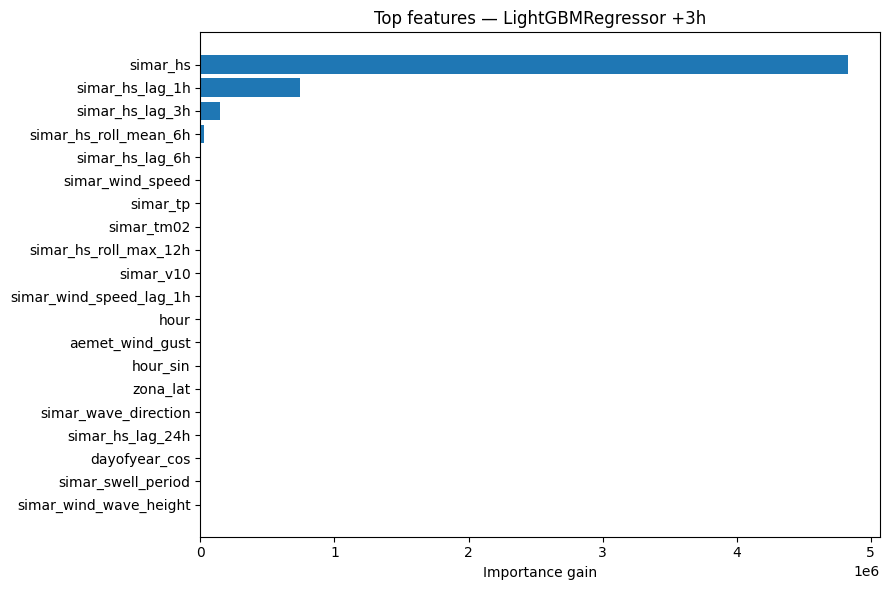

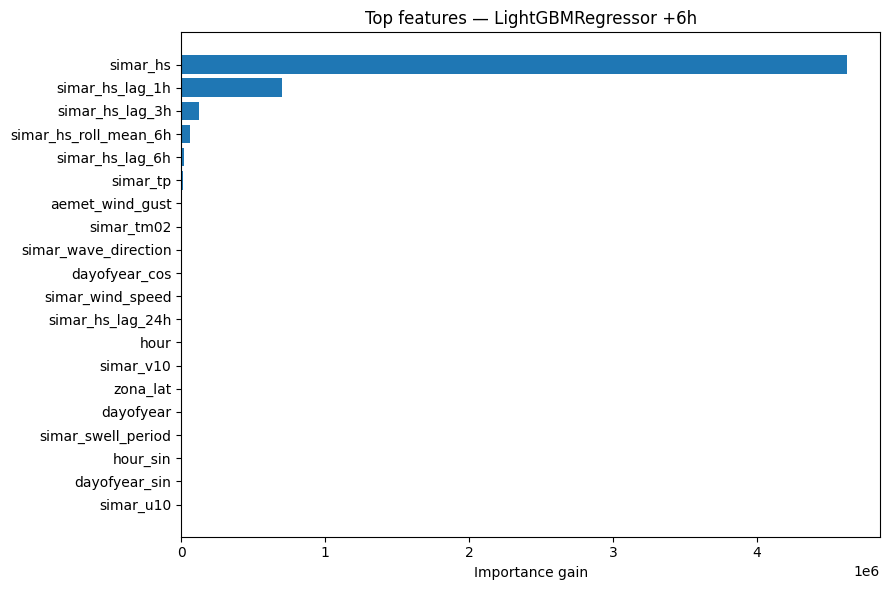

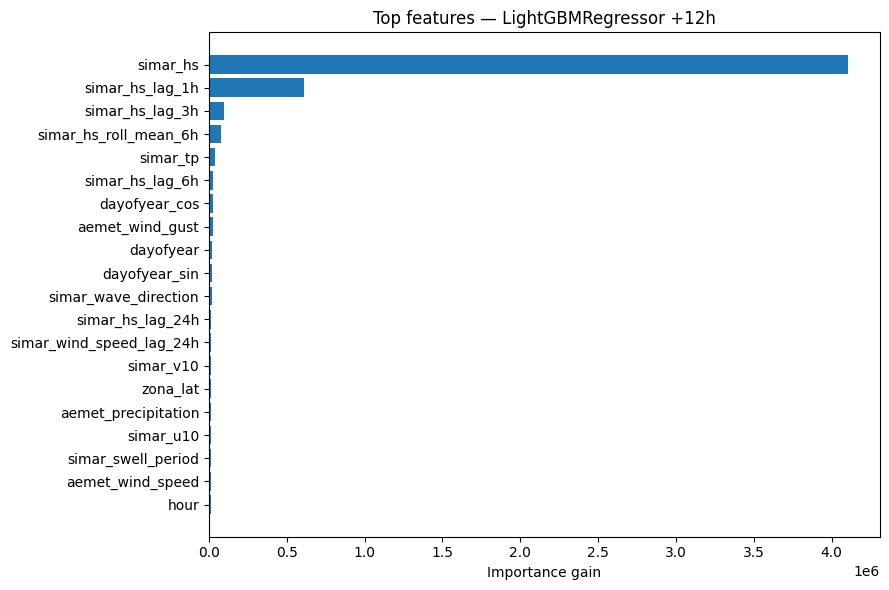

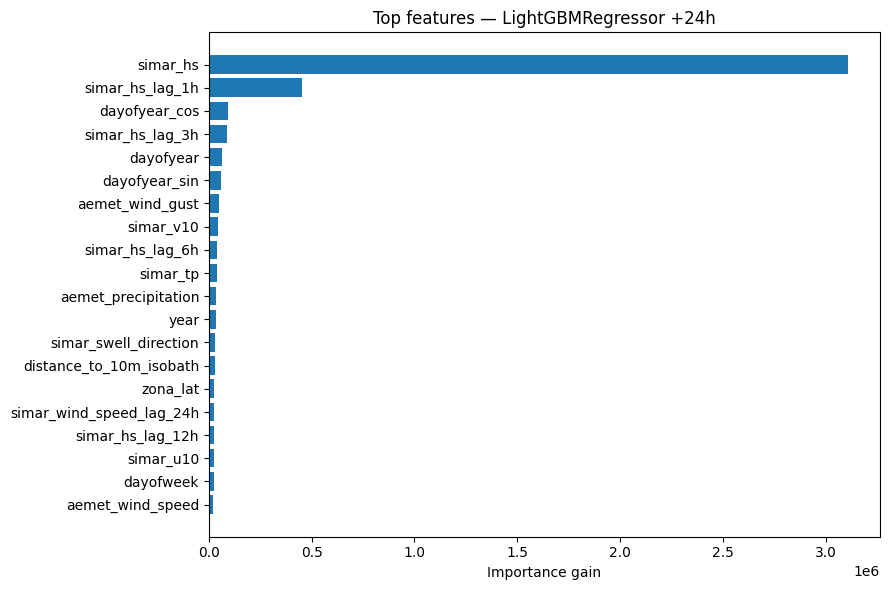

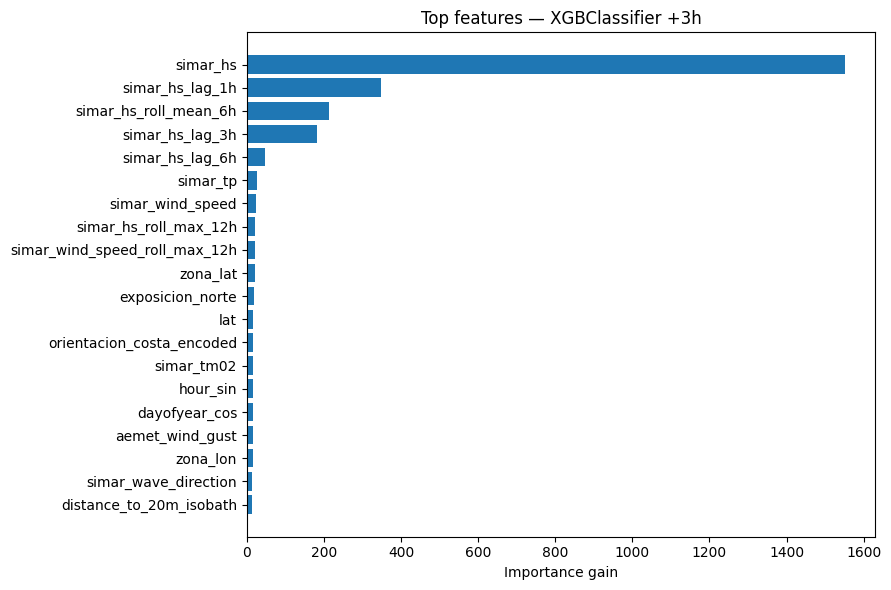

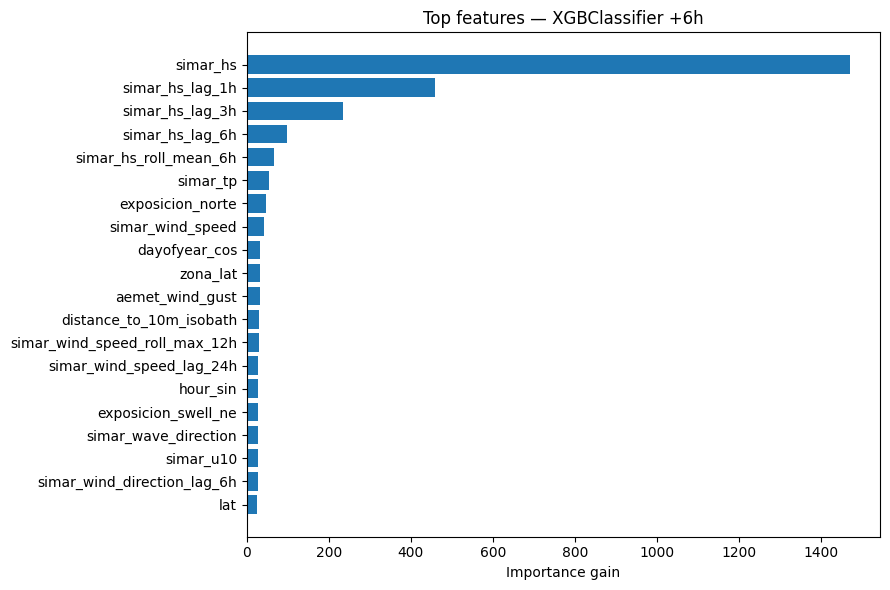

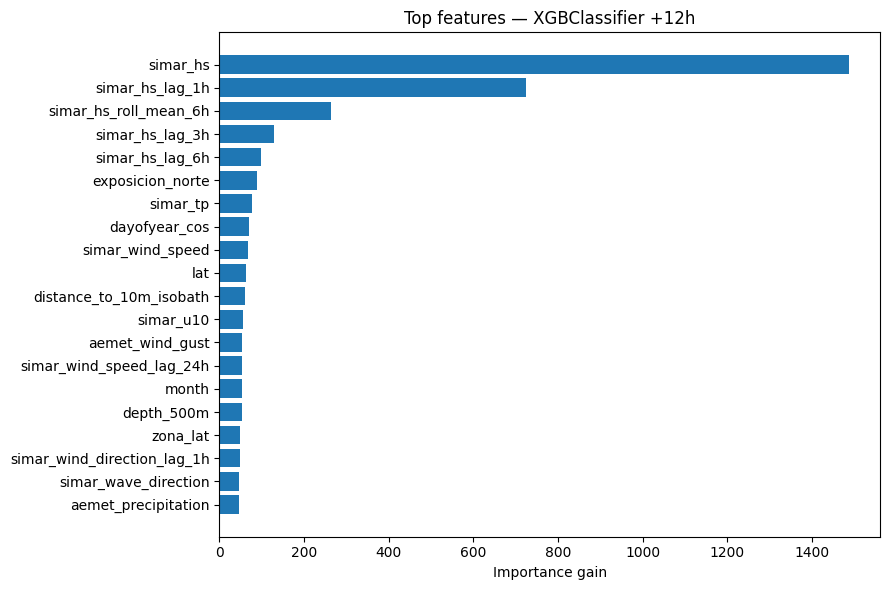

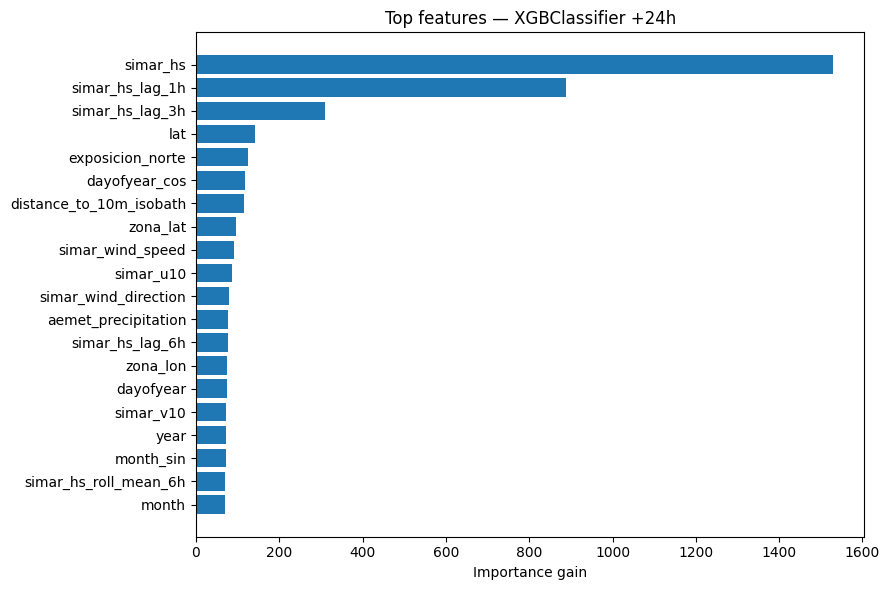

In [15]:
lgbm_importance = load_csv_optional(LGBM_DIR / "feature_importance.csv")
xgb_importance = load_csv_optional(XGB_DIR / "feature_importance.csv")

importance_comparison_rows = []

if not lgbm_importance.empty:
    tmp = lgbm_importance.copy()
    tmp["model_family"] = "LightGBMRegressor"
    importance_comparison_rows.append(tmp)

if not xgb_importance.empty:
    tmp = xgb_importance.copy()
    tmp["model_family"] = "XGBClassifier"
    importance_comparison_rows.append(tmp)

if importance_comparison_rows:
    importance_all = pd.concat(importance_comparison_rows, ignore_index=True)
    importance_all.to_csv(OUT_DIR / "comparison_feature_importance_all.csv", index=False)

    top_importance = (
        importance_all
        .sort_values(["model_family", "horizon_hours", "importance_gain"], ascending=[True, True, False])
        .groupby(["model_family", "horizon_hours"])
        .head(20)
        .reset_index(drop=True)
    )

    top_importance.to_csv(OUT_DIR / "comparison_feature_importance_top20.csv", index=False)
    display(top_importance)

    for model_family in top_importance["model_family"].unique():
        for h in HORIZONS_HOURS:
            plot_df = top_importance[
                (top_importance["model_family"] == model_family)
                & (top_importance["horizon_hours"] == h)
            ].sort_values("importance_gain", ascending=True)

            if plot_df.empty:
                continue

            plt.figure(figsize=(9, 6))
            plt.barh(plot_df["feature"], plot_df["importance_gain"])
            plt.xlabel("Importance gain")
            plt.title(f"Top features — {model_family} +{h}h")
            plt.tight_layout()
            plt.savefig(OUT_DIR / f"plot_top_features_{model_family}_h{h}.png", dpi=150)
            plt.show()
else:
    print("No se encontraron ficheros de importancia de variables.")

## Celda 15 — Informe final de comparación

In [16]:
# Resumen ejecutivo automático.
executive_rows = []

for h in HORIZONS_HOURS:
    risk_subset = risk_test[risk_test["horizon_hours"] == h]
    rec_row = recommendation_summary[recommendation_summary["horizon_hours"] == h].iloc[0]

    lgbm = risk_subset[risk_subset["model"] == "LightGBMRegressor_risk_derived"].iloc[0]
    xgb = risk_subset[risk_subset["model"] == "XGBClassifier_direct_risk"].iloc[0]
    pers = risk_subset[risk_subset["model"] == "PersistenceRisk"].iloc[0]

    executive_rows.append(
        {
            "horizon_hours": h,
            "recommended_model": rec_row["recommended_model"],
            "persistence_macro_f1": pers["macro_f1"],
            "lgbm_macro_f1": lgbm["macro_f1"],
            "xgb_macro_f1": xgb["macro_f1"],
            "persistence_balanced_accuracy": pers["balanced_accuracy"],
            "lgbm_balanced_accuracy": lgbm["balanced_accuracy"],
            "xgb_balanced_accuracy": xgb["balanced_accuracy"],
            "lgbm_recall_class_3": lgbm["recall_class_3"],
            "xgb_recall_class_3": xgb["recall_class_3"],
            "score_lgbm": rec_row["score_lgbm"],
            "score_xgb": rec_row["score_xgb"],
            "notes": rec_row["reason"],
        }
    )

executive_summary = pd.DataFrame(executive_rows)
executive_summary.to_csv(OUT_DIR / "executive_model_comparison_summary.csv", index=False)

display(executive_summary)

comparison_config = {
    "description": "Comparison LightGBMRegressor risk derived vs XGBClassifier direct risk.",
    "input_dirs": {
        "lightgbm": str(LGBM_DIR),
        "xgboost_risk": str(XGB_DIR),
    },
    "output_dir": str(OUT_DIR),
    "horizons_hours": HORIZONS_HOURS,
    "risk_classes": RISK_CLASSES,
    "risk_thresholds": RISK_THRESHOLDS,
    "recommendation_score": {
        "macro_f1": 0.35,
        "balanced_accuracy": 0.30,
        "recall_class_3": 0.20,
        "recall_class_2": 0.15,
    },
    "generated_files": [
        "lgbm_regression_metrics_recalculated.csv",
        "lgbm_risk_metrics_recalculated.csv",
        "xgb_risk_metrics_recalculated.csv",
        "comparison_risk_metrics.csv",
        "comparison_risk_metrics_test_wide.csv",
        "comparison_lightgbm_vs_xgboost_test.csv",
        "recommendation_by_horizon.csv",
        "executive_model_comparison_summary.csv",
    ],
}

save_json(comparison_config, OUT_DIR / "model_comparison_config.json")

,horizon_hours,recommended_model,persistence_macro_f1,lgbm_macro_f1,xgb_macro_f1,persistence_balanced_accuracy,lgbm_balanced_accuracy,xgb_balanced_accuracy,lgbm_recall_class_3,xgb_recall_class_3,score_lgbm,score_xgb,notes
0,3,XGBClassifier_direct_risk,0.909224,0.939179,0.930576,0.909337,0.934673,0.946344,0.917236,0.958092,0.931645,0.941127,Mejor score compuesto de seguridad.
1,6,XGBClassifier_direct_risk,0.840787,0.883351,0.869121,0.841002,0.871643,0.894486,0.821012,0.895014,0.865020,0.882085,Mejor score compuesto de seguridad.
2,12,XGBClassifier_direct_risk,0.740397,0.785569,0.766844,0.740646,0.762452,0.798065,0.643482,0.744989,0.748132,0.771998,Mejor score compuesto de seguridad.
3,24,XGBClassifier_direct_risk,0.614795,0.629172,0.622502,0.614597,0.596647,0.665456,0.299902,0.597165,0.554471,0.627762,Mejor score compuesto de seguridad.


## Celda 16 — Validación final

In [17]:
required_files = [
    OUT_DIR / "lgbm_regression_metrics_recalculated.csv",
    OUT_DIR / "lgbm_risk_metrics_recalculated.csv",
    OUT_DIR / "xgb_risk_metrics_recalculated.csv",
    OUT_DIR / "comparison_risk_metrics.csv",
    OUT_DIR / "comparison_lightgbm_vs_xgboost_test.csv",
    OUT_DIR / "recommendation_by_horizon.csv",
    OUT_DIR / "executive_model_comparison_summary.csv",
    OUT_DIR / "model_comparison_config.json",
]

missing = [str(p) for p in required_files if not p.exists()]

if missing:
    raise FileNotFoundError("Faltan archivos requeridos: " + json.dumps(missing, indent=2))

if executive_summary.empty:
    raise ValueError("executive_summary está vacío.")

if recommendation_summary["recommended_model"].isna().any():
    raise ValueError("Hay horizontes sin recomendación.")

print("Archivos generados en comparación:")
for p in sorted(OUT_DIR.glob("*")):
    print("-", p)

print("\nRecomendación por horizonte:")
display(recommendation_summary)

print("\n✅ Comparación LightGBM vs XGBoost completada correctamente.")

Archivos generados en comparación:
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison/comparison_feature_importance_all.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison/comparison_feature_importance_top20.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison/comparison_lightgbm_vs_xgboost_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison/comparison_risk_metrics.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison/comparison_risk_metrics_test_wide.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison/confusion_matrix_LightGBMRegressor_risk_derived_h12_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison/confusion_matrix_LightGBMRegressor_risk_derived_h12_val.csv
- /content/drive/MyDriv

,horizon_hours,recommended_model,score_lgbm,score_xgb,score_delta_xgb_minus_lgbm,reason
0,3,XGBClassifier_direct_risk,0.931645,0.941127,0.009482,Mejor score compuesto de seguridad.
1,6,XGBClassifier_direct_risk,0.865020,0.882085,0.017065,Mejor score compuesto de seguridad.
2,12,XGBClassifier_direct_risk,0.748132,0.771998,0.023867,Mejor score compuesto de seguridad.
3,24,XGBClassifier_direct_risk,0.554471,0.627762,0.073291,Mejor score compuesto de seguridad.



✅ Comparación LightGBM vs XGBoost completada correctamente.


## Resultado esperado

Al final debe aparecer:

```text
✅ Comparación LightGBM vs XGBoost completada correctamente.
```

Archivos principales:

```text
gold/model_results/model_comparison/lgbm_regression_metrics_recalculated.csv
gold/model_results/model_comparison/lgbm_risk_metrics_recalculated.csv
gold/model_results/model_comparison/xgb_risk_metrics_recalculated.csv
gold/model_results/model_comparison/comparison_risk_metrics.csv
gold/model_results/model_comparison/comparison_lightgbm_vs_xgboost_test.csv
gold/model_results/model_comparison/recommendation_by_horizon.csv
gold/model_results/model_comparison/executive_model_comparison_summary.csv
```

Interpretación:

```text
- LightGBMRegressor es el modelo principal para hs.
- Para riesgo, comparar LightGBM derivado vs XGBClassifier directo.
- Si XGB mejora macro_f1/balanced_accuracy/recall clase 3, usarlo como clasificador de riesgo.
- Si LightGBM gana o empata, mantener riesgo derivado por simplicidad.
```

Siguiente paso posible:

```text
13_model_training_tcn.ipynb
```

o, si antes se quiere cerrar resultados clásicos:

```text
12D_model_final_report.ipynb
```